# Tanzania's Climate: Basic Exploration

## Step 1: Importing the Data

In this step, we load the required datasets using Pandas and NumPy and perform an initial inspection of the Tanzania climate dataset.


In [13]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/tanzania.csv")
df["Country"] = "Tanzania"
df["date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["date"].dt.month
df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


## Step 2: Cleaning the Data

This step involves handling missing values, correcting data types, removing inconsistencies, and preparing the dataset for analysis.


In [14]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,Tanzania,2026-03-27,3
4104,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,Tanzania,2026-03-28,3
4105,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,Tanzania,2026-03-29,3
4106,2026,89,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72,Tanzania,2026-03-30,3


In [15]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()


Duplicate rows: 0


In [16]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


In [17]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "missing": missing,
    "percent": missing_pct
})

missing_df

,missing,percent
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [18]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(zscore(df[cols], nan_policy='omit'))

outliers = (z_scores > 3).sum()
print(outliers)

102


In [19]:
# Drop rows with >30% missing
threshold = int(df.shape[1] * 0.7)
df = df.dropna(thresh=threshold)

# Forward fill
df.ffill()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,Tanzania,2026-03-27,3
4104,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,Tanzania,2026-03-28,3
4105,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,Tanzania,2026-03-29,3
4106,2026,89,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72,Tanzania,2026-03-30,3


In [20]:
df.to_csv("../data/tanzania_clean.csv", index=False)

## Step 3: Exploration of the Data

We analyze Tanzania’s climate data to identify patterns, trends, and seasonal behavior across the years.


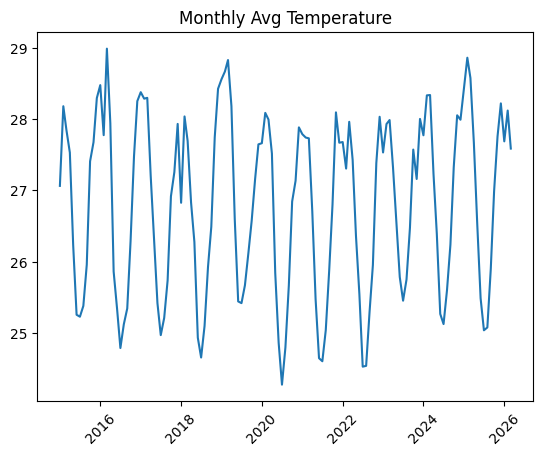

In [21]:
import matplotlib.pyplot as plt

monthly_temp = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()

monthly_temp["date"] = pd.to_datetime(
    monthly_temp["YEAR"].astype(str) + "-" + monthly_temp["Month"].astype(str)
)

plt.figure()
plt.plot(monthly_temp["date"], monthly_temp["T2M"])
plt.title("Monthly Avg Temperature")
plt.xticks(rotation=45)
plt.show()

## Interpretation 1: Monthly Average Temperature (2015–2026)

The analysis of Tanzania’s monthly average temperature from 2015 to 2026 shows generally higher temperature values compared to countries such as Ethiopia and Kenya.

Overall, Tanzania maintains a **consistently warm climate**, with relatively small fluctuations compared to the other datasets. The **lowest temperature values occur around 2020**, approximately in the mid-year period, indicating a temporary cooling phase within the dataset.

The **highest temperature is recorded around 2025**, reaching close to **29°C**, which represents one of the highest temperature peaks in the dataset. Another noticeable peak appears around **2017**, suggesting occasional warm spikes throughout the time series.

Unlike Ethiopia or Nigeria, Tanzania does not show a strong long-term increasing or decreasing trend. Instead, the temperature pattern is mostly influenced by **regular annual variation**, with relatively stable but warm conditions throughout the period.

In summary, Tanzania’s temperature pattern is characterized by:
- Generally higher temperatures compared to Ethiopia and Kenya  
- A low point around 2020  
- Peak temperatures around 2017 and 2025  
- A stable long-term pattern with only minor fluctuations  


<Figure size 640x480 with 0 Axes>

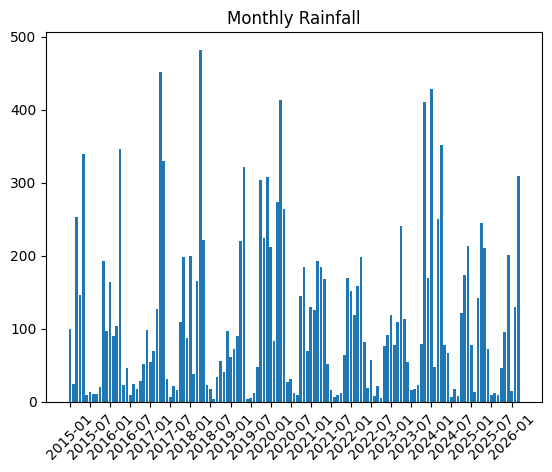

In [22]:
monthly_rain = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()
plt.figure()
monthly_rain = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()

# Create a label column for the x-axis
monthly_rain["label"] = monthly_rain["YEAR"].astype(str) + "-" + monthly_rain["Month"].astype(str).str.zfill(2)

plt.figure()
plt.bar(monthly_rain["label"], monthly_rain["PRECTOTCORR"])

step = 6
plt.xticks(
    ticks=range(0, len(monthly_rain), step),
    labels=monthly_rain["label"][::step],
    rotation=45
)

plt.title("Monthly Rainfall")
plt.show()

## Interpretation 2: Monthly Rainfall Patterns (2015–2026)

The monthly rainfall data for Tanzania shows strong variability with frequent extreme peaks and significant differences between wet and dry periods.

A key observation is the presence of **very high rainfall values**, with some peaks reaching close to **500 mm**, particularly around **July 2017 (2017-07)**. This represents one of the most extreme rainfall events in the dataset.

In addition to this peak, there are multiple rainfall values ranging between **350 mm and 500 mm**, indicating repeated high-intensity rainfall periods throughout the dataset.

However, the data also shows periods of **very low or nearly zero rainfall**, especially around **2019 and 2022**, suggesting strong seasonal or interannual drought-like conditions.

Overall, Tanzania’s rainfall pattern is highly unstable, showing:
- Extremely high rainfall peaks (up to ~500 mm)  
- Major peak around mid-2017  
- Strong variability between wet and dry years  
- Occasional near-zero rainfall periods (notably 2019 and 2022)  

This indicates that Tanzania experiences **highly fluctuating rainfall patterns**, with no stable long-term rainfall trend but strong seasonal and yearly extremes.

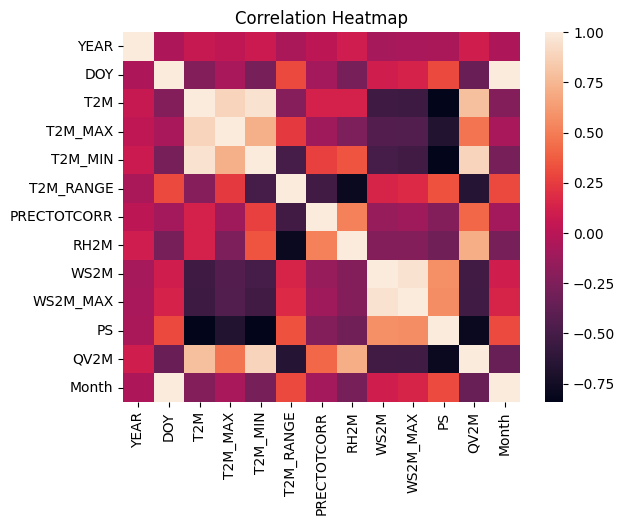

In [23]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=False)
plt.title("Correlation Heatmap")
plt.show()

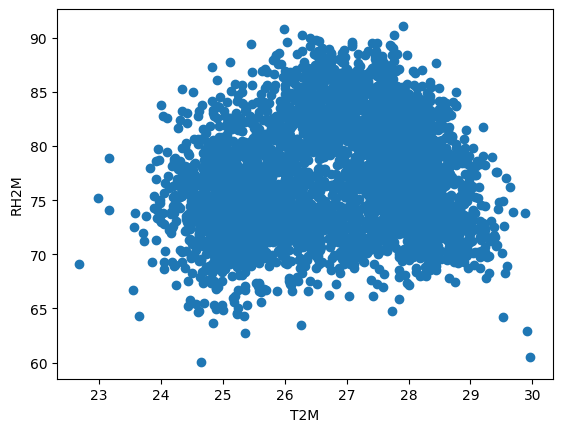

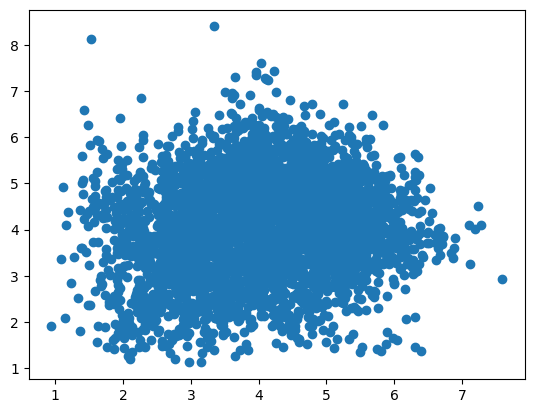

In [24]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.show()

df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

plt.figure()
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.show()

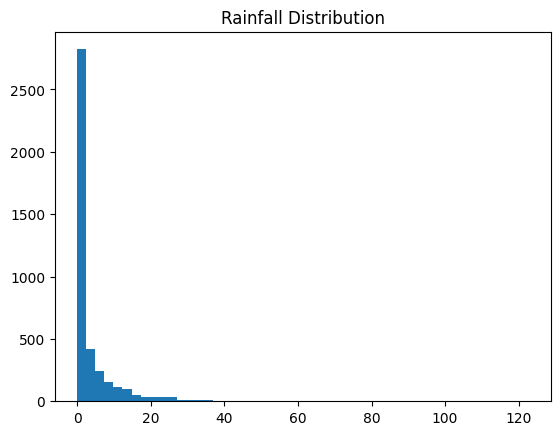

In [25]:
plt.figure()
plt.hist(df["PRECTOTCORR"].dropna(), bins=50)
plt.title("Rainfall Distribution")
plt.show()

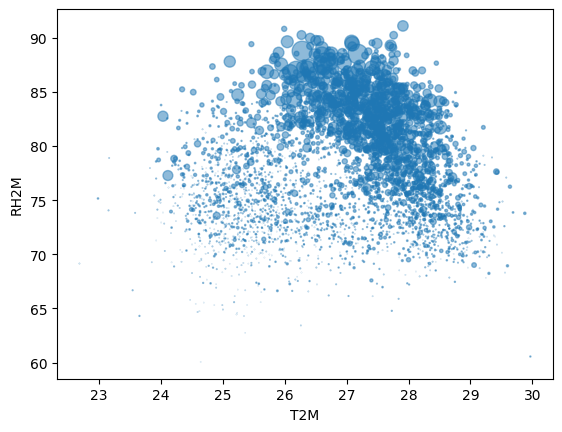

In [26]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*2, alpha=0.5)
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.show()